<a href="https://colab.research.google.com/github/kareemullah123456789/multimodal_seminar/blob/main/multimodal_llm_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Complete Guide to Multimodal LLMs: From Vision Transformers to Practice

This notebook provides a comprehensive journey through multimodal Large Language Models (LLMs), starting from the fundamentals of vision transformers.

## 📚 What You'll Learn:
1. Vision Transformers (ViT) - The foundation
2. How vision and language models combine
3.  Multimodal architectures (CLIP, LLaVA, etc.)
4.  Hands-on implementation with modern models
5.  Practical applications

**Note:** This notebook works best with GPU runtime.  Go to Runtime > Change runtime type > Select T4 GPU

## 1️⃣ Part 1: Vision Transformers (ViT) Fundamentals

### What is a Vision Transformer?

Vision Transformers apply the transformer architecture (originally designed for text) to images:
- Images are split into **patches** (like tokens in text)
- Each patch is embedded into a vector
- Self-attention captures relationships between patches
- No convolutions needed!

Let's visualize this concept:

In [1]:
# Install required packages
!pip install -q transformers torch torchvision pillow matplotlib numpy datasets accelerate

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


### Visualizing Image Patches

Let's see how an image is divided into patches:

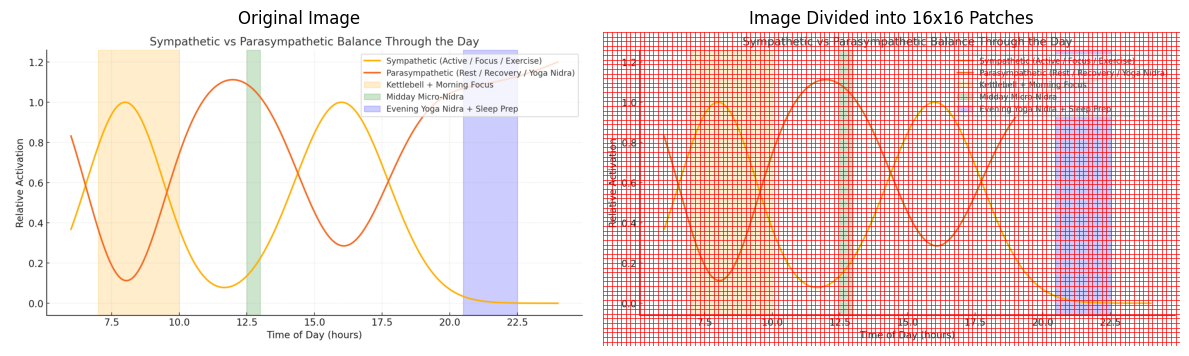

Image size: 2000x1088
Patch size: 16x16
Total patches: 8500


In [6]:
def visualize_image_patches(image_path, patch_size=16):
    """
    Load an image (from URL or local path) and visualize how it's divided into patches
    """
    # Load image from URL or local file
    if image_path.startswith('http://') or image_path. startswith('https://'):
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        # Local file path
        img = Image.open(image_path).convert('RGB')

    # Resize to be divisible by patch_size
    width, height = img.size
    new_width = (width // patch_size) * patch_size
    new_height = (height // patch_size) * patch_size
    img = img.resize((new_width, new_height))

    img_array = np.array(img)

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Original image
    axes[0].imshow(img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Image with patch grid
    axes[1].imshow(img)
    axes[1].set_title(f'Image Divided into {patch_size}x{patch_size} Patches')

    # Draw grid
    for i in range(0, new_height, patch_size):
        axes[1].axhline(i, color='red', linewidth=0.5)
    for j in range(0, new_width, patch_size):
        axes[1].axvline(j, color='red', linewidth=0.5)

    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    num_patches = (new_height // patch_size) * (new_width // patch_size)
    print(f"Image size: {new_width}x{new_height}")
    print(f"Patch size: {patch_size}x{patch_size}")
    print(f"Total patches: {num_patches}")

    return img

# Test with your local image
image_path = "/content/output.png"  # or use a URL
img = visualize_image_patches(image_path, patch_size=16)

### Building a Simple Vision Transformer from Scratch

In [7]:
class PatchEmbedding(nn. Module):
    """Split image into patches and embed them"""
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # Use a convolution to extract patches and embed them
        self.projection = nn.Conv2d(in_channels, embed_dim,
                                    kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: (batch, channels, height, width)
        x = self.projection(x)  # (batch, embed_dim, num_patches_h, num_patches_w)
        x = x.flatten(2)         # (batch, embed_dim, num_patches)
        x = x.transpose(1, 2)    # (batch, num_patches, embed_dim)
        return x

class SimpleViT(nn.Module):
    """Simplified Vision Transformer"""
    def __init__(self, img_size=224, patch_size=16, embed_dim=768, num_heads=12, num_classes=1000):
        super().__init__()

        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        # Class token (learnable)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Position embedding
        self.pos_embed = nn. Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads,
                                                   dim_feedforward=embed_dim*4, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=12)

        # Classification head
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        batch_size = x.shape[0]

        # Patch embedding
        x = self.patch_embed(x)  # (batch, num_patches, embed_dim)

        # Add class token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (batch, num_patches+1, embed_dim)

        # Add position embedding
        x = x + self.pos_embed

        # Transformer encoding
        x = self.transformer(x)

        # Classification using class token
        x = self.head(x[:, 0])  # Use only the class token

        return x

# Create and test the model
model = SimpleViT(img_size=224, patch_size=16). to(device)
dummy_input = torch.randn(1, 3, 224, 224).to(device)
output = model(dummy_input)
print(f"Model output shape: {output.shape}")
print(f"Number of parameters: {sum(p. numel() for p in model. parameters()):,}")

Model output shape: torch.Size([1, 1000])
Number of parameters: 86,566,120


### Using Pre-trained Vision Transformer

Now let's use a real pre-trained ViT model:

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

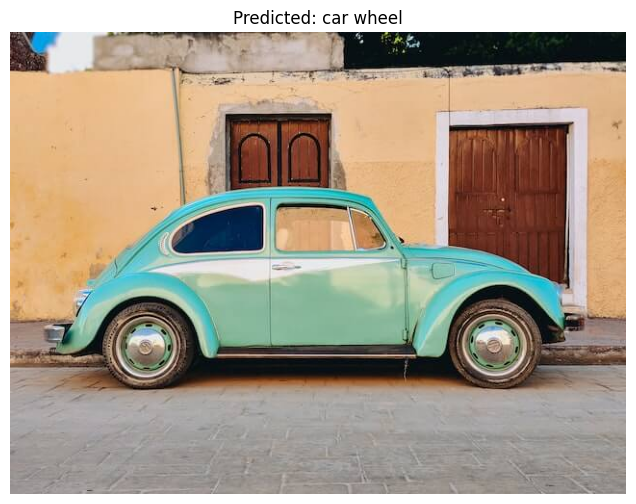


Top 5 predictions:
1. car wheel: 21.51%
2. sports car, sport car: 20.84%
3. beach wagon, station wagon, wagon, estate car, beach waggon, station waggon, waggon: 17.17%
4. convertible: 11.71%
5. pickup, pickup truck: 7.76%


In [8]:
from transformers import ViTImageProcessor, ViTForImageClassification

# Load pre-trained ViT model
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
vit_model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')
vit_model = vit_model.to(device)

def classify_image(image_url):
    # Load image
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)).convert('RGB')

    # Process image
    inputs = processor(images=image, return_tensors="pt"). to(device)

    # Get predictions
    with torch.no_grad():
        outputs = vit_model(**inputs)
        logits = outputs.logits
        predicted_class = logits.argmax(-1).item()

    # Display result
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(f"Predicted: {vit_model.config.id2label[predicted_class]}")
    plt.axis('off')
    plt.show()

    # Show top 5 predictions
    probs = torch.softmax(logits, dim=-1)[0]
    top5_prob, top5_idx = torch.topk(probs, 5)
    print("\nTop 5 predictions:")
    for i, (prob, idx) in enumerate(zip(top5_prob, top5_idx)):
        print(f"{i+1}. {vit_model.config.id2label[idx.item()]}: {prob.item():.2%}")

# Test the model
classify_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg")

## 2️⃣ Part 2: Understanding Multimodal Models

### What is a Multimodal LLM?

Multimodal LLMs combine different types of data (vision, text, audio) into a single model:

**Key Components:**
1. **Vision Encoder**: Processes images (often a ViT)
2. **Language Model**: Processes and generates text
3. **Projection Layer**: Bridges vision and language representations
4.  **Training Strategy**: Contrastive learning, alignment, etc.

### Popular Architectures:
- **CLIP**: Contrastive Language-Image Pre-training
- **LLaVA**: Large Language and Vision Assistant
- **BLIP**: Bootstrapping Language-Image Pre-training
- **Flamingo**: DeepMind's multimodal model

### Example 1: CLIP - Connecting Images and Text

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

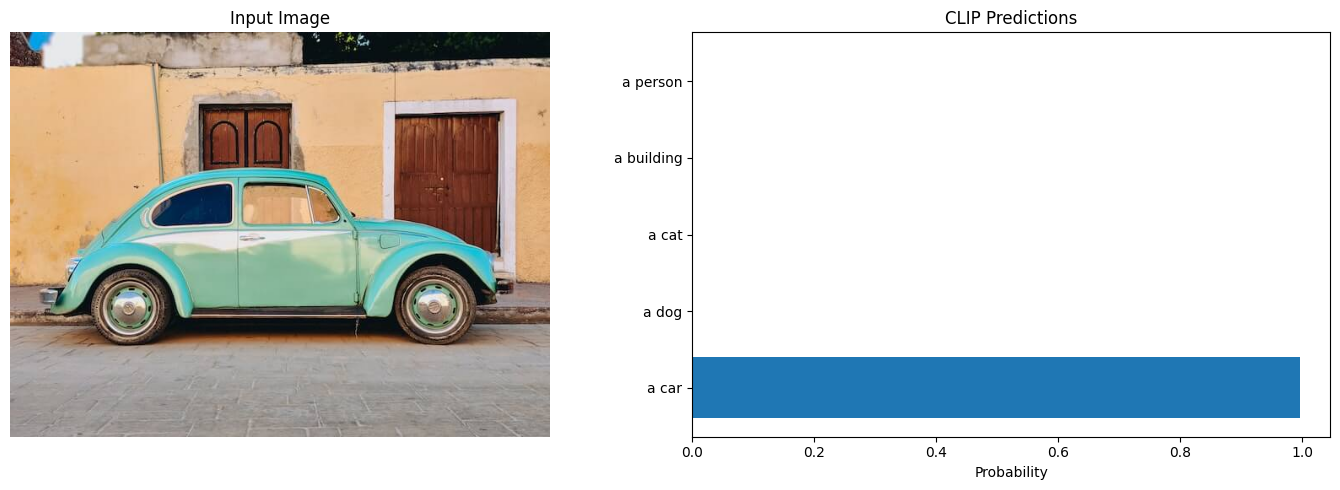


Predictions:
a car: 99.68%
a dog: 0.06%
a cat: 0.11%
a building: 0.05%
a person: 0.11%


In [9]:
from transformers import CLIPProcessor, CLIPModel

# Load CLIP model
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = clip_model. to(device)

def clip_zero_shot_classification(image_url, candidate_labels):
    """
    Zero-shot image classification using CLIP
    """
    # Load image
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)).convert('RGB')

    # Process inputs
    inputs = clip_processor(text=candidate_labels, images=image,
                           return_tensors="pt", padding=True).to(device)

    # Get predictions
    with torch.no_grad():
        outputs = clip_model(**inputs)
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1)

    # Display results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Show image
    ax1.imshow(image)
    ax1.set_title('Input Image')
    ax1.axis('off')

    # Show probabilities
    probs_np = probs.cpu().numpy()[0]
    ax2.barh(candidate_labels, probs_np)
    ax2.set_xlabel('Probability')
    ax2.set_title('CLIP Predictions')

    plt. tight_layout()
    plt.show()

    # Print results
    print("\nPredictions:")
    for label, prob in zip(candidate_labels, probs_np):
        print(f"{label}: {prob:.2%}")

# Test CLIP
labels = ["a car", "a dog", "a cat", "a building", "a person"]
clip_zero_shot_classification(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg",
    labels
)

### CLIP Image-Text Similarity

CLIP can find images that match text descriptions:

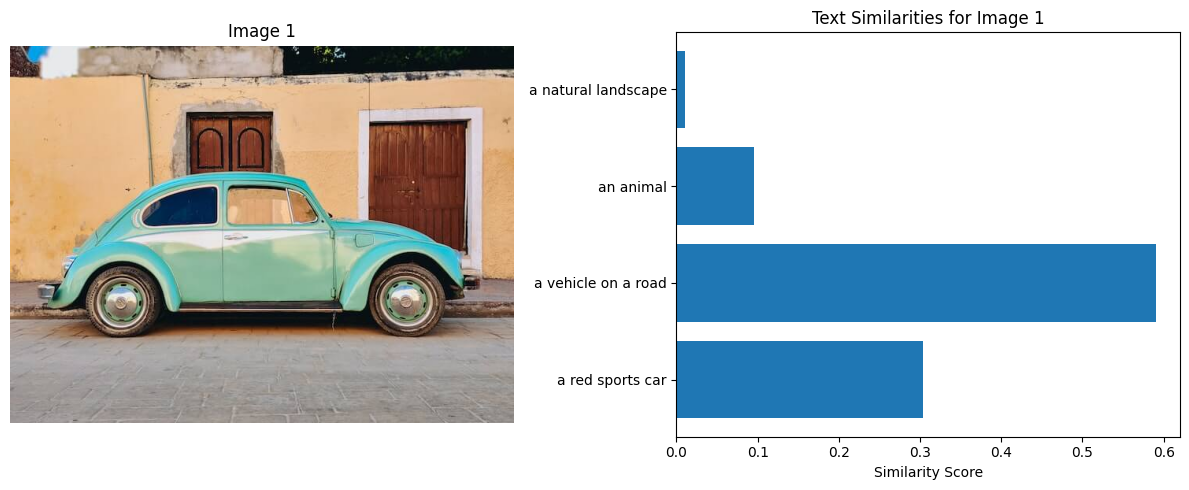

In [10]:
def image_text_similarity(image_urls, text_queries):
    """
    Compute similarity between multiple images and text queries
    """
    # Load images
    images = []
    for url in image_urls:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        images.append(img)

    # Process inputs
    inputs = clip_processor(text=text_queries, images=images,
                           return_tensors="pt", padding=True).to(device)

    # Compute similarity
    with torch.no_grad():
        outputs = clip_model(**inputs)
        logits_per_image = outputs.logits_per_image  # (num_images, num_texts)
        probs = logits_per_image.softmax(dim=1). cpu().numpy()

    # Visualize
    fig, axes = plt.subplots(len(images), 2, figsize=(12, 5*len(images)))
    if len(images) == 1:
        axes = axes.reshape(1, -1)

    for i, (img, prob_row) in enumerate(zip(images, probs)):
        # Show image
        axes[i, 0].imshow(img)
        axes[i, 0]. set_title(f'Image {i+1}')
        axes[i, 0].axis('off')

        # Show similarities
        axes[i, 1].barh(text_queries, prob_row)
        axes[i, 1].set_xlabel('Similarity Score')
        axes[i, 1].set_title(f'Text Similarities for Image {i+1}')

    plt.tight_layout()
    plt.show()

# Test with multiple images
test_images = [
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg",
]
test_queries = [
    "a red sports car",
    "a vehicle on a road",
    "an animal",
    "a natural landscape"
]
image_text_similarity(test_images, test_queries)

## 3️⃣ Part 3: Vision-Language Models (VLMs)

### BLIP: Image Captioning and Visual Question Answering

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

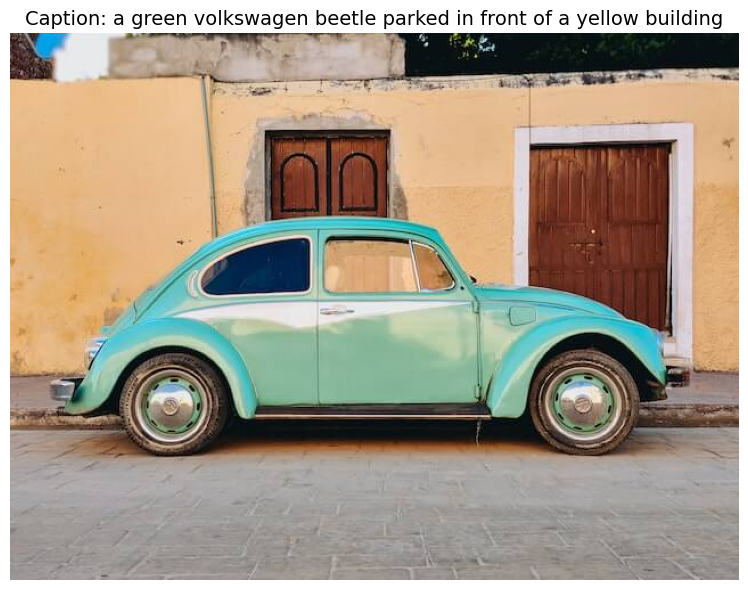


Generated caption: a green volkswagen beetle parked in front of a yellow building


In [11]:
from transformers import BlipProcessor, BlipForConditionalGeneration, BlipForQuestionAnswering

# Load BLIP for image captioning
blip_processor = BlipProcessor. from_pretrained("Salesforce/blip-image-captioning-base")
blip_caption_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

def generate_caption(image_url):
    """
    Generate captions for an image using BLIP
    """
    # Load image
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)).convert('RGB')

    # Process and generate caption
    inputs = blip_processor(image, return_tensors="pt").to(device)

    # Generate caption
    with torch.no_grad():
        out = blip_caption_model. generate(**inputs, max_length=50)

    caption = blip_processor.decode(out[0], skip_special_tokens=True)

    # Display
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.title(f"Caption: {caption}", fontsize=14, wrap=True)
    plt.axis('off')
    plt. tight_layout()
    plt.show()

    return caption

# Test image captioning
caption = generate_caption(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"
)
print(f"\nGenerated caption: {caption}")

### Visual Question Answering (VQA)

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

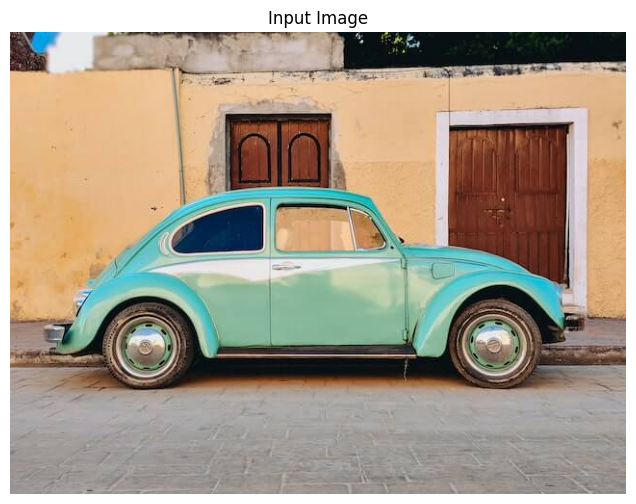


Question Answering:

Q: What color is the car?
A: blue

Q: What type of vehicle is this?
A: volkswagen beetle

Q: Is this indoors or outdoors?
A: outdoors

Q: How many vehicles are visible?
A: 1


In [12]:
# Load BLIP for VQA
vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
vqa_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)

def visual_question_answering(image_url, questions):
    """
    Answer questions about an image
    """
    # Load image
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)).convert('RGB')

    # Display image
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.title('Input Image')
    plt.axis('off')
    plt.show()

    print("\nQuestion Answering:")
    print("=" * 50)

    # Answer each question
    for question in questions:
        inputs = vqa_processor(image, question, return_tensors="pt"). to(device)

        with torch.no_grad():
            out = vqa_model. generate(**inputs, max_length=20)

        answer = vqa_processor.decode(out[0], skip_special_tokens=True)
        print(f"\nQ: {question}")
        print(f"A: {answer}")

# Test VQA
questions = [
    "What color is the car?",
    "What type of vehicle is this?",
    "Is this indoors or outdoors?",
    "How many vehicles are visible?"
]

visual_question_answering(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg",
    questions
)

## 4️⃣ Part 4: Modern Multimodal LLMs

### Using LLaVA (Large Language and Vision Assistant)

LLaVA combines a vision encoder with a large language model (LLaMA) for more sophisticated visual understanding.

In [14]:
# First, clear all previous models from GPU
import gc
import torch

# Delete previous models
if 'vit_model' in globals():
    del vit_model
if 'clip_model' in globals():
    del clip_model
if 'blip_caption_model' in globals():
    del blip_caption_model
if 'vqa_model' in globals():
    del vqa_model

# Clear GPU cache
gc.collect()
torch.cuda.empty_cache()

print("GPU Memory cleared!")
print(f"Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"Reserved: {torch. cuda.memory_reserved(0) / 1024**3:.2f} GB")

GPU Memory cleared!
Allocated: 11.24 GB
Reserved: 13.17 GB


In [17]:
# Install bitsandbytes for quantization
! pip install -q bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 14.4 MB/s eta 0:00:00


In [18]:
# Step 1: Install required packages
#!pip install -q bitsandbytes accelerate

# Step 2: Clear GPU memory
import gc
import torch

# Delete previous models
model_names = ['vit_model', 'clip_model', 'blip_caption_model', 'vqa_model',
               'llava_model', 'blip2_model', 'instruct_model']
for model_name in model_names:
    if model_name in globals():
        del globals()[model_name]

gc.collect()
torch.cuda. empty_cache()

print("GPU Memory cleared!")
print(f"Allocated: {torch.cuda. memory_allocated(0) / 1024**3:.2f} GB")
print(f"Reserved: {torch. cuda.memory_reserved(0) / 1024**3:.2f} GB")

GPU Memory cleared!
Allocated: 0.45 GB
Reserved: 0.48 GB


In [ ]:
# Clear memory
import gc
gc.collect()
torch.cuda.empty_cache()

# Load BLIP-2 (works without bitsandbytes)
from transformers import Blip2Processor, Blip2ForConditionalGeneration

print("Loading BLIP-2 (3B parameters, more memory efficient)...")

blip2_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
blip2_model = Blip2ForConditionalGeneration. from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16,
    device_map="auto"
)

print("✓ BLIP-2 loaded successfully!")
print(f"GPU Memory used: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")

def chat_with_image_blip2(image_source, prompt):
    """
    Chat with image using BLIP-2
    """
    image = load_image(image_source)

    # BLIP-2 uses "Question: ...  Answer:" format
    inputs = blip2_processor(images=image, text=prompt, return_tensors="pt").to("cuda", torch.float16)

    print("Generating response...")
    with torch.no_grad():
        generated_ids = blip2_model.generate(
            **inputs,
            max_new_tokens=200,
            num_beams=5,
            temperature=1.0
        )

    response = blip2_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]. strip()

    # Display
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.title('Input Image')
    plt.axis('off')
    plt.show()

    print("\n" + "="*70)
    print(f"Prompt: {prompt}")
    print("="*70)
    print(f"Response:\n{response}")
    print("="*70)

    return response

# Test multiple prompts
prompts = [
    "Question: What is in this image?  Answer:",
    "Question: Describe this image in detail. Answer:",
    "Question: What are the main colors in this image? Answer:",
    "Question: What is the style of this image? Answer:"
]

for prompt in prompts:
    print(f"\n{'='*70}\n")
    chat_with_image_blip2("/content/output.png", prompt)

Loading BLIP-2 (3B parameters, more memory efficient)...


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/10.0G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

In [ ]:
def chat_with_image(image_url, prompt):
    """
    Have a conversation about an image using LLaVA
    """
    # Load image
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)).convert('RGB')

    # Prepare conversation
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image"},
            ],
        },
    ]

    # Process inputs
    text_prompt = llava_processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = llava_processor(images=image, text=text_prompt, return_tensors="pt").to(device)

    # Generate response
    print("Generating response...")
    with torch.no_grad():
        output = llava_model. generate(**inputs, max_new_tokens=200)

    # Decode response
    response_text = llava_processor. decode(output[0], skip_special_tokens=True)

    # Display
    plt. figure(figsize=(10, 6))
    plt.imshow(image)
    plt.title('Input Image')
    plt.axis('off')
    plt. show()

    print("\n" + "="*70)
    print(f"Prompt: {prompt}")
    print("="*70)
    print(f"Response:\n{response_text}")
    print("="*70)

# Test LLaVA with complex prompts
chat_with_image(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg",
    "Describe this image in detail.  What can you tell me about the vehicle, the setting, and any other notable features?"
)

## 5️⃣ Part 5: Building Your Own Simple Multimodal Model

Let's create a simplified multimodal architecture to understand the key components:

In [ ]:
class SimpleMultimodalModel(nn.Module):
    """
    A simplified multimodal model that combines vision and text
    """
    def __init__(self, vision_dim=768, text_dim=768, hidden_dim=512, num_classes=10):
        super().__init__()

        # Vision encoder (simplified - in practice, use ViT)
        self. vision_encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),
            nn. ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7)),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, vision_dim)
        )

        # Text encoder (simplified - in practice, use BERT/GPT)
        self.text_encoder = nn. Embedding(10000, text_dim)
        self.text_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=text_dim, nhead=8, batch_first=True),
            num_layers=4
        )

        # Multimodal fusion
        self. fusion = nn.Sequential(
            nn.Linear(vision_dim + text_dim, hidden_dim),
            nn.ReLU(),
            nn. Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        # Output head
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, image, text):
        # Encode image
        vision_features = self.vision_encoder(image)  # (batch, vision_dim)

        # Encode text
        text_embeddings = self.text_encoder(text)  # (batch, seq_len, text_dim)
        text_features = self.text_transformer(text_embeddings)
        text_features = text_features.mean(dim=1)  # Pool over sequence

        # Fuse modalities
        combined = torch.cat([vision_features, text_features], dim=1)
        fused_features = self.fusion(combined)

        # Classify
        output = self.classifier(fused_features)

        return output

# Create and test the model
multimodal_model = SimpleMultimodalModel(). to(device)

# Test with dummy data
dummy_image = torch.randn(2, 3, 224, 224).to(device)
dummy_text = torch.randint(0, 10000, (2, 20)).to(device)

output = multimodal_model(dummy_image, dummy_text)
print(f"Output shape: {output.shape}")
print(f"Number of parameters: {sum(p.numel() for p in multimodal_model.parameters()):,}")

print("\n✅ Multimodal model architecture created successfully!")
print("\nKey components:")
print("1. Vision Encoder: Processes images into feature vectors")
print("2. Text Encoder: Processes text into feature vectors")
print("3. Fusion Layer: Combines vision and text features")
print("4.  Classifier: Makes final predictions")

## 6️⃣ Part 6: Practical Applications

### Application 1: Visual Search Engine

In [ ]:
def visual_search_engine(query, candidate_images):
    """
    Search for images that match a text query using CLIP
    """
    # Load images
    images = []
    for url in candidate_images:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        images.append(img)

    # Process
    inputs = clip_processor(text=[query], images=images,
                           return_tensors="pt", padding=True).to(device)

    # Compute similarities
    with torch.no_grad():
        outputs = clip_model(**inputs)
        similarities = outputs.logits_per_image[:, 0]. cpu().numpy()

    # Sort by similarity
    sorted_indices = np.argsort(similarities)[::-1]

    # Display results
    n_results = min(3, len(images))
    fig, axes = plt.subplots(1, n_results, figsize=(15, 5))
    if n_results == 1:
        axes = [axes]

    for i, idx in enumerate(sorted_indices[:n_results]):
        axes[i].imshow(images[idx])
        axes[i].set_title(f"Rank {i+1}\nSimilarity: {similarities[idx]:.3f}")
        axes[i].axis('off')

    plt.suptitle(f'Search Results for: "{query}"', fontsize=14)
    plt.tight_layout()
    plt.show()

# Example: Search for images
search_query = "a red vehicle"
image_database = [
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg",
    "https://images.unsplash.com/photo-1568605117036-5fe5e7bab0b7? w=400",  # Car
    "https://images.unsplash. com/photo-1583511655857-d19b40a7a54e?w=400",  # Dog
]

print(f"🔍 Searching for: '{search_query}'\n")
visual_search_engine(search_query, image_database)

### Application 2: Image Understanding Pipeline

In [ ]:
def complete_image_analysis(image_url):
    """
    Comprehensive image analysis using multiple models
    """
    print("🔬 Complete Image Analysis Pipeline")
    print("=" * 70)

    # Load image
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)).convert('RGB')

    # Display image
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.title('Input Image')
    plt.axis('off')
    plt.show()

    # 1. Image Classification (ViT)
    print("\n1️⃣ Image Classification (Vision Transformer)")
    print("-" * 70)
    inputs = processor(images=image, return_tensors="pt"). to(device)
    with torch.no_grad():
        outputs = vit_model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[0]
        top3_prob, top3_idx = torch. topk(probs, 3)

    for i, (prob, idx) in enumerate(zip(top3_prob, top3_idx)):
        print(f"   {i+1}. {vit_model.config.id2label[idx.item()]}: {prob.item():.2%}")

    # 2. Image Captioning (BLIP)
    print("\n2️⃣ Image Captioning (BLIP)")
    print("-" * 70)
    inputs = blip_processor(image, return_tensors="pt"). to(device)
    with torch.no_grad():
        out = blip_caption_model. generate(**inputs, max_length=50)
    caption = blip_processor.decode(out[0], skip_special_tokens=True)
    print(f"   Caption: {caption}")

    # 3. Zero-shot Classification (CLIP)
    print("\n3️⃣ Semantic Understanding (CLIP)")
    print("-" * 70)
    concepts = ["transportation", "nature", "technology", "urban scene", "indoor scene"]
    inputs = clip_processor(text=concepts, images=image,
                           return_tensors="pt", padding=True).to(device)
    with torch. no_grad():
        outputs = clip_model(**inputs)
        probs = outputs.logits_per_image. softmax(dim=1)[0]

    for concept, prob in zip(concepts, probs):
        print(f"   {concept}: {prob.item():.2%}")

    # 4. Visual Question Answering
    print("\n4️⃣ Visual Question Answering (BLIP-VQA)")
    print("-" * 70)
    questions = [
        "What is the main object?",
        "What is the setting?",
        "What colors are visible?"
    ]

    for question in questions:
        inputs = vqa_processor(image, question, return_tensors="pt").to(device)
        with torch. no_grad():
            out = vqa_model. generate(**inputs, max_length=20)
        answer = vqa_processor.decode(out[0], skip_special_tokens=True)
        print(f"   Q: {question}")
        print(f"   A: {answer}")

    print("\n" + "=" * 70)
    print("✅ Analysis Complete!")

# Run complete analysis
complete_image_analysis(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"
)

## 🎓 Summary and Key Takeaways

### What We Covered:

1. **Vision Transformers (ViT)**
   - How images are converted to patches
   - Transformer architecture for vision
   - Self-attention on image patches

2. **Multimodal Models**
   - **CLIP**: Connects images and text through contrastive learning
   - **BLIP**: Image captioning and VQA
   - **LLaVA**: Large language model + vision encoder

3. **Key Concepts**
   - **Patch Embedding**: Converting images to token sequences
   - **Cross-modal Alignment**: Bridging vision and language
   - **Zero-shot Learning**: Classifying without training examples
   - **Visual Question Answering**: Reasoning about images

4. **Applications**
   - Visual search engines
   - Image understanding pipelines
   - Content moderation
   - Accessibility tools

### Next Steps:

1. **Fine-tuning**: Adapt these models to your specific use case
2. **Prompt Engineering**: Experiment with different prompts for better results
3. **Quantization**: Use 4-bit/8-bit quantization for larger models
4. **Multi-image**: Explore models that can handle multiple images
5. **Video Understanding**: Extend to video analysis

### Resources:

- [Hugging Face Transformers](https://huggingface.co/docs/transformers)
- [Vision Transformer Paper](https://arxiv.org/abs/2010.11929)
- [CLIP Paper](https://arxiv.org/abs/2103.00020)
- [LLaVA Paper](https://arxiv.org/abs/2304.08485)
- [BLIP Paper](https://arxiv.org/abs/2201.12086)

### Try It Yourself!  🚀

Modify the code cells above with your own:
- Images (use any URL)
- Questions for VQA
- Text prompts for CLIP
- Custom prompts for LLaVA


## 🧪 Bonus: Interactive Playground

Try the models with your own images!

In [ ]:
# Interactive cell - modify these variables!

YOUR_IMAGE_URL = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"
YOUR_QUESTION = "What is this?"
YOUR_LABELS = ["a car", "a dog", "a cat", "a building", "food"]

print("🎮 Interactive Multimodal LLM Playground")
print("=" * 70)

# Load and display image
response = requests.get(YOUR_IMAGE_URL)
image = Image.open(BytesIO(response.content)). convert('RGB')
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt. title('Your Image')
plt.axis('off')
plt.show()

# CLIP Classification
print("\n📊 CLIP Classification:")
inputs = clip_processor(text=YOUR_LABELS, images=image,
                       return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    outputs = clip_model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1)[0]

for label, prob in zip(YOUR_LABELS, probs):
    print(f"   {label}: {prob.item():.2%}")

# Image Caption
print("\n💬 Generated Caption:")
inputs = blip_processor(image, return_tensors="pt").to(device)
with torch.no_grad():
    out = blip_caption_model.generate(**inputs, max_length=50)
caption = blip_processor.decode(out[0], skip_special_tokens=True)
print(f"   {caption}")

# VQA
print("\n❓ Answer to Your Question:")
print(f"   Q: {YOUR_QUESTION}")
inputs = vqa_processor(image, YOUR_QUESTION, return_tensors="pt").to(device)
with torch.no_grad():
    out = vqa_model.generate(**inputs, max_length=20)
answer = vqa_processor.decode(out[0], skip_special_tokens=True)
print(f"   A: {answer}")

print("\n" + "=" * 70)
print("✨ Try changing the variables above and run this cell again!")